## Visualizacion de DEMO_H

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_demo = pd.read_csv("../data/demo.csv")


In [3]:
df_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6106 entries, 0 to 6105
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SEQN                    6106 non-null   float64
 1   Genero                  6106 non-null   float64
 2   Edad                    6106 non-null   float64
 3   Etnia                   6106 non-null   float64
 4   Nivel_Educativo         6106 non-null   float64
 5   Estado_Civil            6106 non-null   float64
 6   Ratio_Pobreza           6106 non-null   float64
 7   Servicio_Militar        6106 non-null   float64
 8   Ratio_Pobreza_Faltante  6106 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 429.5 KB


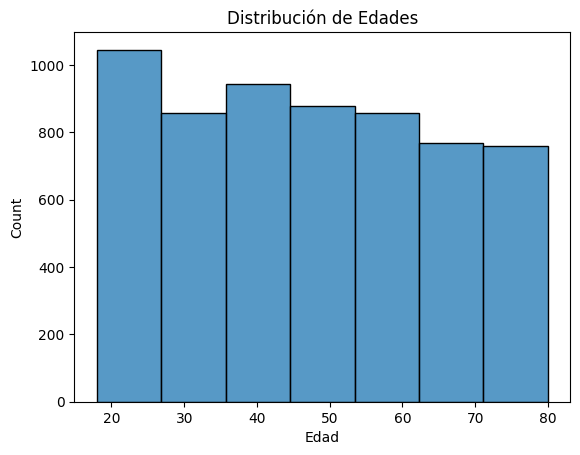

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df_demo, x="Edad", bins=7, kde=False)
plt.title("Distribución de Edades")
plt.show()

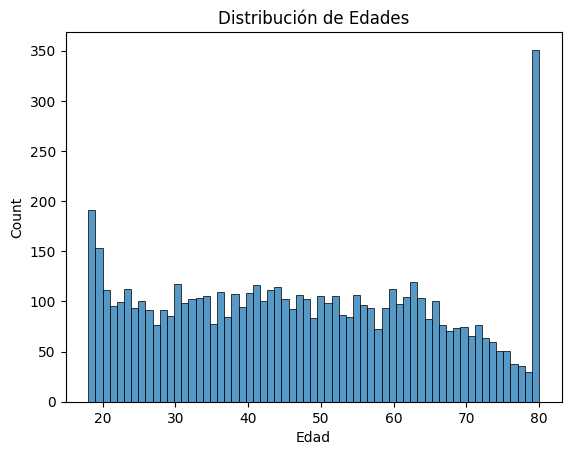

In [5]:
sns.histplot(data=df_demo, x="Edad", bins=63, kde=False)
plt.title("Distribución de Edades")
plt.show()

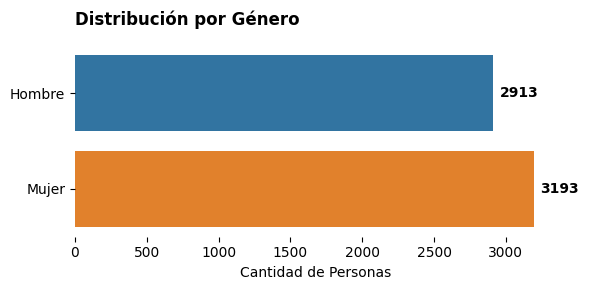

In [6]:
plt.figure(figsize=(6, 3))
ax = sns.countplot(
    data=df_demo, 
    y="Genero", 
    hue="Genero", # Mejora la consistencia visual
    legend=False,
    palette='tab10'
)
plt.yticks(ticks=[0, 1], labels=["Hombre", "Mujer"])
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, fontweight='bold')

plt.title("Distribución por Género", fontsize=12, pad=15, loc='left', fontweight='bold')
plt.xlabel("Cantidad de Personas")
plt.ylabel("") # Quitamos "Genero" porque ya se entiende por las etiquetas
sns.despine(left=True, bottom=True) # Quitamos los bordes innecesarios

plt.tight_layout()
plt.show()

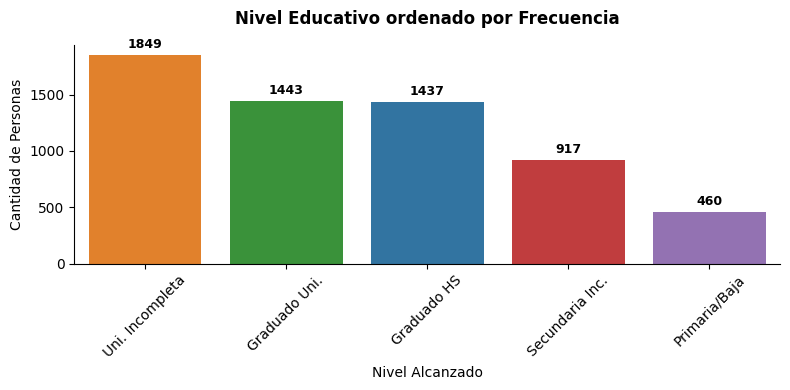

In [7]:
nombres_educacion = {
    1: "Primaria/Baja",
    2: "Secundaria Inc.",
    3: "Graduado HS",
    4: "Uni. Incompleta",
    5: "Graduado Uni."
}

df_demo['Educacion_Label'] = df_demo['Nivel_Educativo'].map(nombres_educacion)

orden_frecuencia = df_demo['Educacion_Label'].value_counts().index

plt.figure(figsize=(8, 4))
ax = sns.countplot(
    x='Educacion_Label', 
    data=df_demo, 
    order=orden_frecuencia, 
    palette='tab10', 
    hue='Educacion_Label',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9, fontweight='bold')

plt.title('Nivel Educativo ordenado por Frecuencia', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nivel Alcanzado')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45)

# Eliminamos bordes para máxima limpieza
sns.despine()

plt.tight_layout()
plt.show()

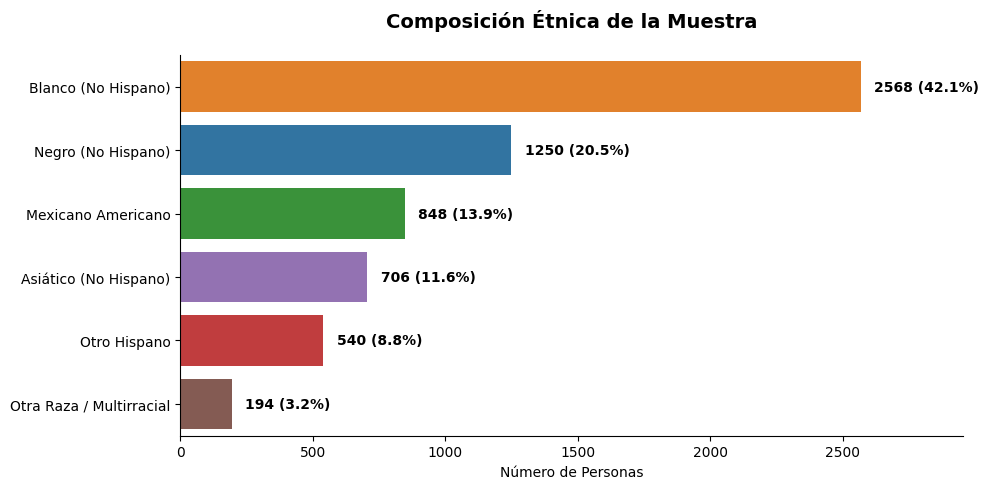

In [8]:
dict_etnia = {
    1: "Mexicano Americano",
    2: "Otro Hispano",
    3: "Blanco (No Hispano)",
    4: "Negro (No Hispano)",
    6: "Asiático (No Hispano)",
    7: "Otra Raza / Multirracial"
}
df_demo['Etnia_Label'] = df_demo['Etnia'].map(dict_etnia)

orden_frecuencia = df_demo['Etnia_Label'].value_counts().index

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df_demo, 
    y='Etnia_Label', 
    order=orden_frecuencia, 
    palette='tab10',
    hue='Etnia_Label',
    legend=False
)

total = len(df_demo)
for p in ax.patches:
    percentage = f'{100 * p.get_width() / total:.1f}%'
    x = p.get_width() + 50 # Un pequeño offset
    y = p.get_y() + p.get_height() / 2
    ax.annotate(f'{int(p.get_width())} ({percentage})', (x, y), va='center', fontweight='bold')

plt.title('Composición Étnica de la Muestra', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Número de Personas')
plt.ylabel('')
plt.xlim(0, df_demo['Etnia_Label'].value_counts().max() * 1.15) # Espacio para que quepan las etiquetas
sns.despine()

plt.tight_layout()
plt.show()

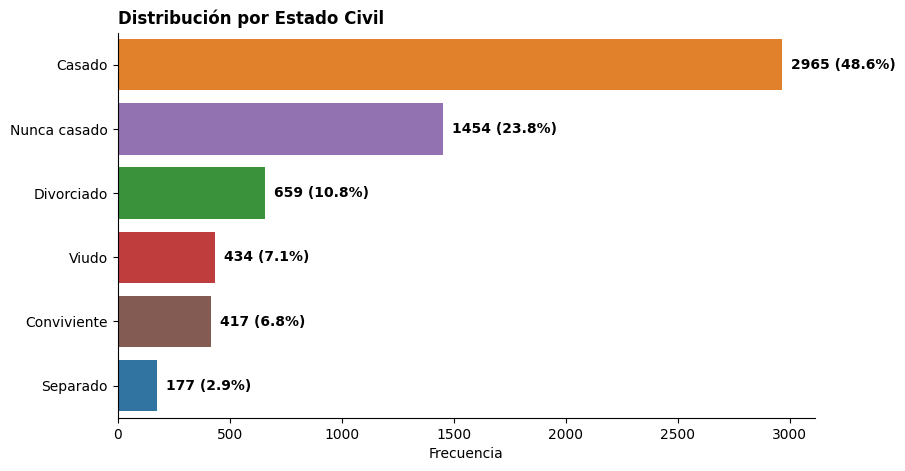

In [9]:
# 1. Diccionario de traducción
dict_civil = {
    1: "Casado",
    2: "Viudo",
    3: "Divorciado",
    4: "Separado",
    5: "Nunca casado",
    6: "Conviviente"
}

# 2. Creamos la columna y filtramos los valores no informativos (77, 99 y NaNs)
df_demo['Estado_Civil_Label'] = df_demo['Estado_Civil'].map(dict_civil)
df_civil_clean = df_demo.dropna(subset=['Estado_Civil_Label'])
plt.figure(figsize=(9, 5))
orden_civil = df_civil_clean['Estado_Civil_Label'].value_counts().index

ax = sns.countplot(
    data=df_civil_clean, 
    y='Estado_Civil_Label', 
    order=orden_civil, 
    palette='tab10',
    hue='Estado_Civil_Label',
    legend=False
)

# Añadimos porcentajes
total_valido = len(df_civil_clean)
for p in ax.patches:
    pct = f'{100 * p.get_width() / total_valido:.1f}%' # pyright: ignore[reportAttributeAccessIssue]
    ax.annotate(f'{int(p.get_width())} ({pct})', 
                (p.get_width() + 40, p.get_y() + p.get_height()/2), 
                va='center', fontweight='bold')

plt.title('Distribución por Estado Civil', loc='left', fontweight='bold')
plt.xlabel('Frecuencia')
plt.ylabel('')
sns.despine()
plt.show()

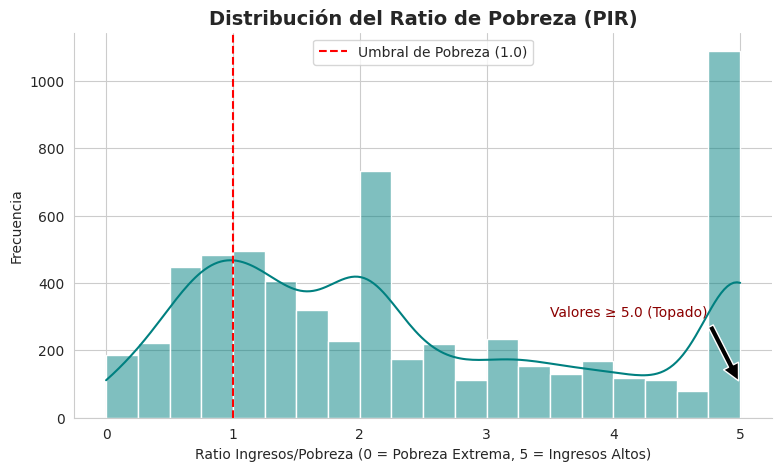

In [10]:
plt.figure(figsize=(9, 5))
sns.set_style("whitegrid")

# Crear el histograma
ax = sns.histplot(data=df_demo, x="Ratio_Pobreza", kde=True, color="teal", bins=20)

# EL TOQUE DE EXPERTO: Añadir la línea del umbral de pobreza
plt.axvline(x=1.0, color='red', linestyle='--', label='Umbral de Pobreza (1.0)')

# Anotación para explicar el "pico" en 5.0
plt.annotate('Valores ≥ 5.0 (Topado)', xy=(5, 100), xytext=(3.5, 300),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, color='darkred')

plt.title('Distribución del Ratio de Pobreza (PIR)', fontsize=14, fontweight='bold')
plt.xlabel('Ratio Ingresos/Pobreza (0 = Pobreza Extrema, 5 = Ingresos Altos)')
plt.ylabel('Frecuencia')
plt.legend()
sns.despine()

plt.show()

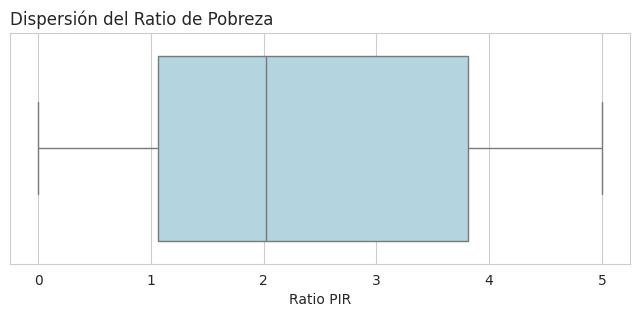

In [11]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df_demo, x="Ratio_Pobreza", color="lightblue", fliersize=3)

plt.title('Dispersión del Ratio de Pobreza', loc='left')
plt.xlabel('Ratio PIR')
plt.show()

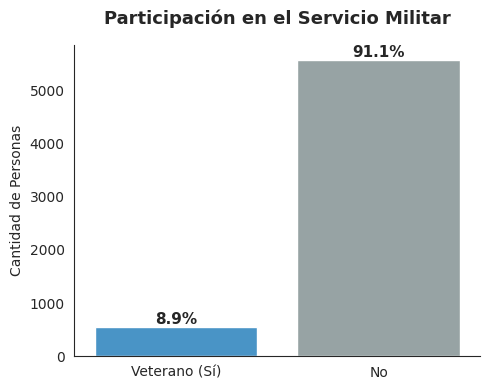

In [12]:
# 1. Mapeo de valores
dict_militar = {1: "Veterano (Sí)", 2: "No"}
df_demo['Servicio_Militar_Label'] = df_demo['Servicio_Militar'].map(dict_militar)

# 2. Configuración estética
plt.figure(figsize=(5, 4))
sns.set_style("white")

# 3. Gráfico de barras
# Usamos una paleta de dos colores contrastantes (Gris para 'No', Azul para 'Veterano')
colores = ["#95a5a6", "#3498db"] # Gris y Azul

ax = sns.countplot(
    data=df_demo.dropna(subset=['Servicio_Militar_Label']), 
    x='Servicio_Militar_Label', 
    palette=colores[::-1], # Invertimos para que Veterano sea azul si es el primero
    hue='Servicio_Militar_Label',
    legend=False
)

# 4. Añadir porcentajes sobre las barras
total = len(df_demo.dropna(subset=['Servicio_Militar_Label']))
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 5), 
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# 5. Limpieza final
plt.title('Participación en el Servicio Militar', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('Cantidad de Personas')
sns.despine()

plt.tight_layout()
plt.show()

## ALQ_H

In [13]:
df_alq = pd.read_csv('../data/alq.csv')

In [14]:
df_alq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5909 entries, 0 to 5908
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SEQN                          5909 non-null   float64
 1   Promedio_Tragos_Dia           5909 non-null   float64
 2   Dias_Con_+4_5_Tragos_En_2hrs  5909 non-null   float64
 3   Consumio_Alcohol              5909 non-null   bool   
 4   Dias_Consumo_Anual            5909 non-null   float64
 5   Dias_Alto_Consumo_Anual       5909 non-null   float64
dtypes: bool(1), float64(5)
memory usage: 236.7 KB


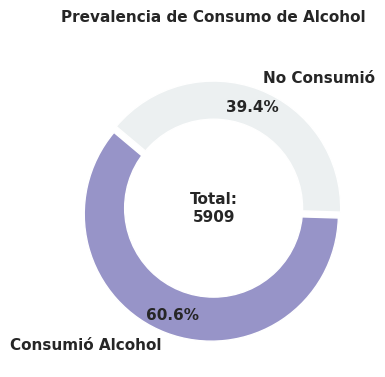

In [15]:
import matplotlib.pyplot as plt

# 1. Preparar los datos
conteo = df_alq['Consumio_Alcohol'].value_counts()
etiquetas = ['Consumió Alcohol', 'No Consumió']
colores = ["#9794c8", '#ecf0f1'] # Gris oscuro (activo) y gris muy claro (neutro)

# 2. Crear el gráfico de dona
plt.figure(figsize=(4, 4))
plt.pie(
    conteo, 
    labels=etiquetas, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colores, 
    pctdistance=0.85, 
    explode=(0.05, 0), # Separa un poco la tajada del "Sí"
    textprops={'fontweight': 'bold', 'fontsize': 11}
)

# 3. Dibujar el círculo blanco central (la dona)
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

# 4. Información central
plt.text(0, 0, f'Total:\n{len(df_alq)}', ha='center', va='center', fontsize=11, fontweight='bold')

plt.title('Prevalencia de Consumo de Alcohol', fontsize=11, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

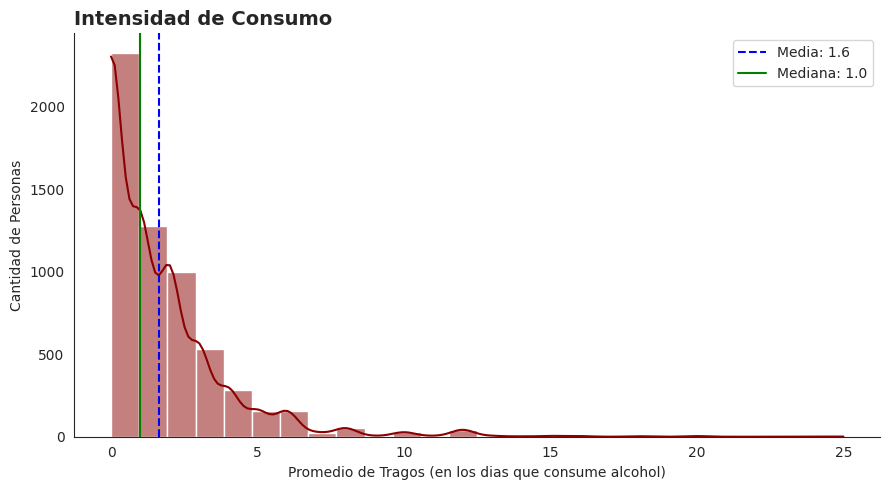

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo
sns.set_style("white")
plt.figure(figsize=(9, 5))

# 2. Creación del gráfico
# Usamos bins para agrupar los tragos y KDE para ver la forma de la distribución
ax = sns.histplot(data=df_alq, x="Promedio_Tragos_Dia", kde=True, color="darkred", bins=26)

# 3. EL TOQUE DE EXPERTO: Añadir líneas de tendencia central
media = df_alq["Promedio_Tragos_Dia"].mean()
mediana = df_alq["Promedio_Tragos_Dia"].median()

plt.axvline(media, color='blue', linestyle='--', label=f'Media: {media:.1f}')
plt.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.1f}')

# 5. Limpieza y etiquetas
plt.title('Intensidad de Consumo', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('Promedio de Tragos (en los dias que consume alcohol)')
plt.ylabel('Cantidad de Personas')
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

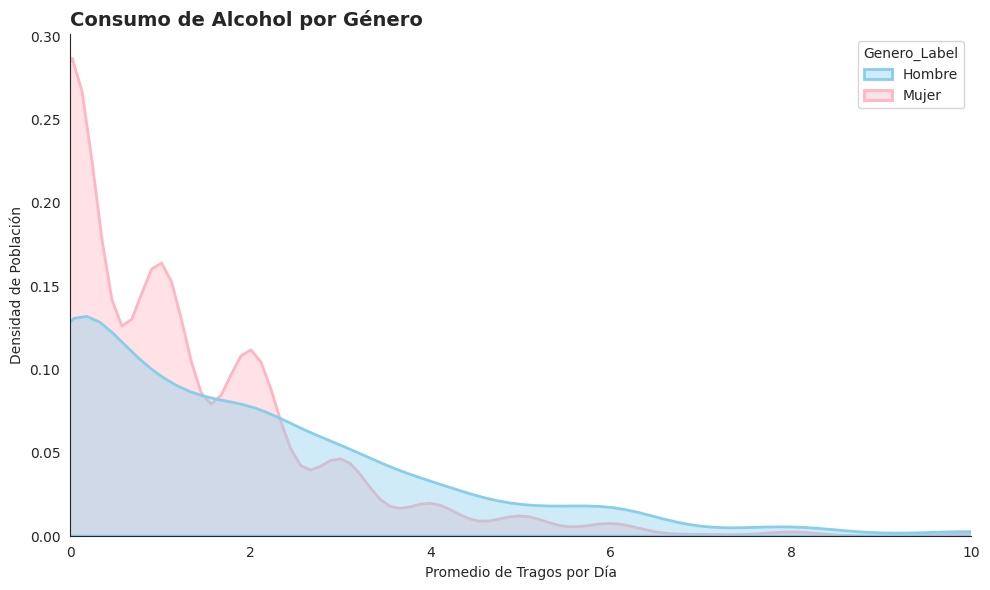

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Unión y preparación (Igual que el tuyo, gemelo)
df_consolidado = pd.merge(df_demo, df_alq[['SEQN', 'Promedio_Tragos_Dia']], on='SEQN', how='inner')
df_consolidado['Genero_Label'] = df_consolidado['Genero'].map({1: "Hombre", 2: "Mujer"})

# 2. Configuración estética
plt.figure(figsize=(10, 6))
sns.set_style("white")

# 3. Gráfico de Densidad
sns.kdeplot(
    data=df_consolidado, 
    x="Promedio_Tragos_Dia", 
    hue="Genero_Label", 
    fill=True, 
    palette=["skyblue", "lightpink"], 
    alpha=0.4, 
    linewidth=2
)

# 4. Cálculo de estadísticas por grupo
stats = df_consolidado.groupby('Genero_Label')['Promedio_Tragos_Dia'].agg(['mean', 'median'])

# 5. Superposición de Media y Mediana
colores = {"Hombre": "steelblue", "Mujer": "palevioletred"}


# 6. Pulido del gráfico
plt.title('Consumo de Alcohol por Género', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('Promedio de Tragos por Día')
plt.ylabel('Densidad de Población')
plt.xlim(0, 10) # Enfocamos en el grueso de la población
sns.despine()

plt.tight_layout()
plt.show()

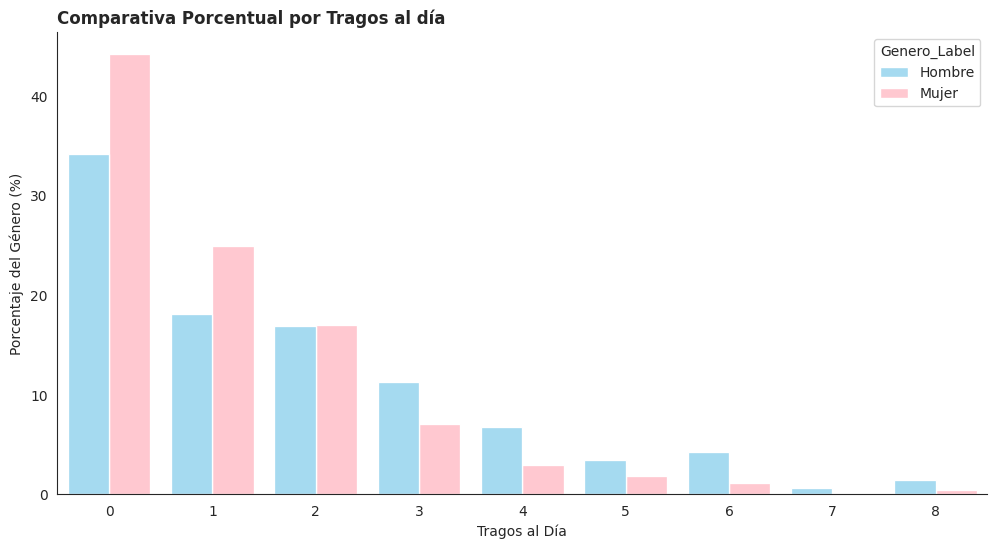

In [18]:
plt.figure(figsize=(12, 6))

# Usamos 'discrete=True' para que las barras caigan exacto en los números
sns.histplot(
    data=df_consolidado,
    x="Promedio_Tragos_Dia",
    hue="Genero_Label",
    multiple="dodge", # Pone las barras una al lado de la otra
    shrink=0.8,       # Les da un poco de aire entre ellas
    palette=["skyblue", "lightpink"],
    discrete=True,
    stat="percent",   # Importante: muestra porcentaje para que sean comparables
    common_norm=False # Calcula el % independiente por cada género
)

plt.title('Comparativa Porcentual por Tragos al día', loc='left', fontweight='bold')
plt.xlabel('Tragos al Día')
plt.ylabel('Porcentaje del Género (%)')
plt.xlim(-0.5, 8.5) # Enfocamos en el grueso de la población
plt.xticks(range(9))
sns.despine()
plt.show()

Asimetría en Hombres: 2.50
Asimetría en Mujeres: 2.98


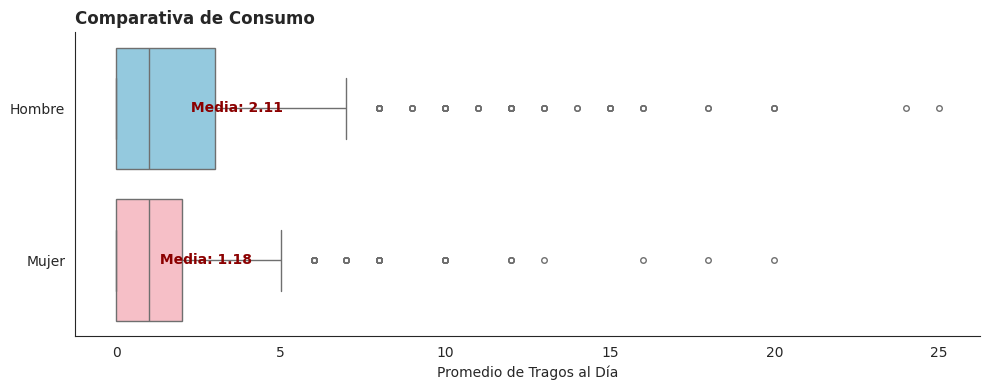

In [19]:
# 1. Calculamos la asimetría por género
skew_h = df_consolidado[df_consolidado['Genero'] == 1]['Promedio_Tragos_Dia'].skew()
skew_m = df_consolidado[df_consolidado['Genero'] == 2]['Promedio_Tragos_Dia'].skew()

print(f"Asimetría en Hombres: {skew_h:.2f}")
print(f"Asimetría en Mujeres: {skew_m:.2f}")

# 2. Visualización: Boxplot con estilo impecable
plt.figure(figsize=(10, 4))
sns.set_style("white")

ax = sns.boxplot(
    data=df_consolidado, 
    x="Promedio_Tragos_Dia", 
    y="Genero_Label", 
    palette=["skyblue", "lightpink"],
    hue="Genero_Label",
    legend=False,
    fliersize=4  # Tamaño de los puntos atípicos
)

# 3. Anotamos las Medias para contrastar con las medianas iguales
medias = df_consolidado.groupby('Genero_Label')['Promedio_Tragos_Dia'].mean()

for i, genero in enumerate(['Hombre', 'Mujer']):
    plt.text(medias[genero], i, f' Media: {medias[genero]:.2f}', 
             va='center', fontweight='bold', color='darkred', fontsize=10)

plt.title('Comparativa de Consumo', loc='left', fontweight='bold')
plt.xlabel('Promedio de Tragos al Día')
plt.ylabel('')
sns.despine()

plt.tight_layout()
plt.show()

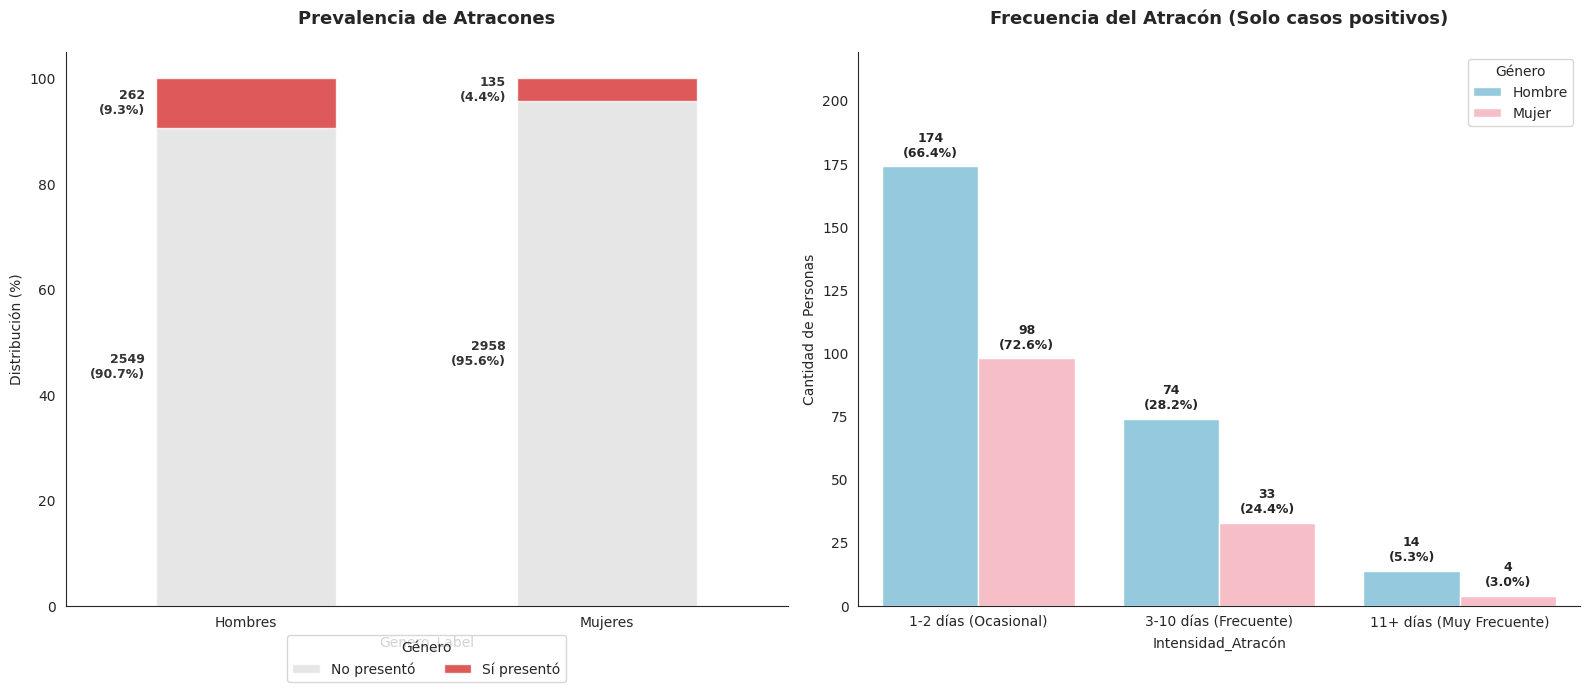

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Preparación de datos (Merge)
df_consolidado = pd.merge(df_demo, df_alq[['SEQN', 'Dias_Con_+4_5_Tragos_En_2hrs']], on='SEQN', how='inner')
df_consolidado['Genero_Label'] = df_consolidado['Genero'].map({1: "Hombre", 2: "Mujer"})

# 2. Categorización
def categorizar_atracón(dias):
    if dias == 0: return "0 días (Nunca)"
    if 1 <= dias <= 2: return "1-2 días (Ocasional)"
    if 3 <= dias <= 10: return "3-10 días (Frecuente)"
    return "11+ días (Muy Frecuente)"

df_consolidado['Intensidad_Atracón'] = df_consolidado['Dias_Con_+4_5_Tragos_En_2hrs'].apply(categorizar_atracón)
df_consolidado['Es_Binge'] = df_consolidado['Dias_Con_+4_5_Tragos_En_2hrs'] > 0

# 3. Configuración de la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("white")

# --- GRÁFICO 1: Prevalencia (%) ---
prevalencia = df_consolidado.groupby(['Genero_Label', 'Es_Binge']).size().unstack(fill_value=0)
prevalencia_pct = prevalencia.div(prevalencia.sum(axis=1), axis=0) * 100

# Forzamos orden de las barras: [0: No, 1: Sí]
prevalencia_pct.plot(kind='bar', stacked=True, ax=ax1, color=['#e0e0e0', '#d63031'], alpha=0.8)

# ANOTACIONES EN GRÁFICO 1 (A la IZQUIERDA)
for i, genero in enumerate(prevalencia_pct.index):
    cum_height = 0
    for j, col in enumerate(prevalencia_pct.columns):
        height = prevalencia_pct.loc[genero, col]
        cantidad = prevalencia.loc[genero, col]
        
        # Posición: x es el índice (0 o 1), y es el centro del segmento
        y_pos = cum_height + (height / 2)
        x_pos = i - 0.28 # Ajuste a la izquierda de la barra
        
        ax1.text(x_pos, y_pos, f'{int(cantidad)}\n({height:.1f}%)', 
                 ha='right', va='center', fontweight='bold', fontsize=9, color='#333')
        cum_height += height

ax1.set_title('Prevalencia de Atracones', fontsize=13, fontweight='bold', pad=20)
ax1.set_ylabel('Distribución (%)')
ax1.set_xticklabels(["Hombres", "Mujeres"], rotation=0)
ax1.legend(['No presentó', 'Sí presentó'], loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2,title="Género")

# --- GRÁFICO 2: Intensidad ---
df_si = df_consolidado[df_consolidado['Dias_Con_+4_5_Tragos_En_2hrs'] > 0]
orden_intensidad = ["1-2 días (Ocasional)", "3-10 días (Frecuente)", "11+ días (Muy Frecuente)"]
totales_por_genero = df_si['Genero_Label'].value_counts()

# Dibujamos el countplot con hue_order explícito para evitar confusiones
ax2 = sns.countplot(
    data=df_si, 
    x='Intensidad_Atracón', 
    hue='Genero_Label', 
    hue_order=["Hombre", "Mujer"],
    order=orden_intensidad,
    palette=["skyblue", "lightpink"],
    ax=ax2
)

# ANOTACIONES EN GRÁFICO 2 (Cantidad y % real)
# Iteramos por los contenedores de Seaborn (cada uno es un género)
for i, container in enumerate(ax2.containers):
    genero = "Hombre" if i == 0 else "Mujer"
    total_g = totales_por_genero[genero]
    
    # Añadimos la etiqueta a cada barra del contenedor
    labels = [f'{int(v.get_height())}\n({(v.get_height()/total_g*100):.1f}%)' if v.get_height() > 0 else '' for v in container]
    ax2.bar_label(container, labels=labels, padding=5, fontweight='bold', fontsize=9)

ax2.set_title('Frecuencia del Atracón (Solo casos positivos)', fontsize=13, fontweight='bold', pad=20)
ax2.set_ylabel('Cantidad de Personas')
ax2.set_ylim(0, ax2.get_ylim()[1] * 1.2)
ax2.legend(title="Género")

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_277309/760637542.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="Reds", alpha=0.8)


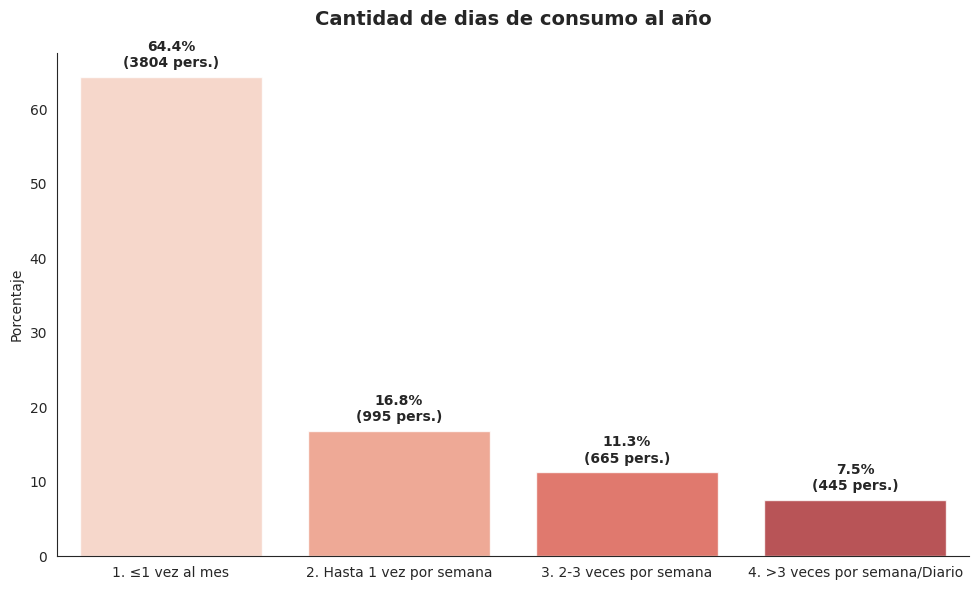

In [21]:
# 1. Definimos categorías de riesgo basadas en la frecuencia anual
def nivel_exposicion(dias):
    if dias <= 12: return "1. ≤1 vez al mes"
    if dias <= 52: return "2. Hasta 1 vez por semana"
    if dias <= 156: return "3. 2-3 veces por semana"
    return "4. >3 veces por semana/Diario"

df_alq['Nivel_Cronicidad'] = df_alq['Dias_Consumo_Anual'].apply(nivel_exposicion)

# 2. Visualización: Gráfico de Barras con Porcentajes
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Calculamos porcentajes para que sea comparable
counts = df_alq['Nivel_Cronicidad'].value_counts(normalize=True).sort_index() * 100

ax = sns.barplot(x=counts.index, y=counts.values, palette="Reds", alpha=0.8)

# Añadimos las etiquetas de porcentaje y cantidad real
for i, p in enumerate(ax.patches):
    count_real = df_alq['Nivel_Cronicidad'].value_counts().sort_index().values[i]
    ax.annotate(f'{p.get_height():.1f}%\n({count_real} pers.)', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontweight='bold')

plt.title('Cantidad de dias de consumo al año', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Porcentaje')
plt.xlabel('')
sns.despine()
plt.tight_layout()
plt.show()

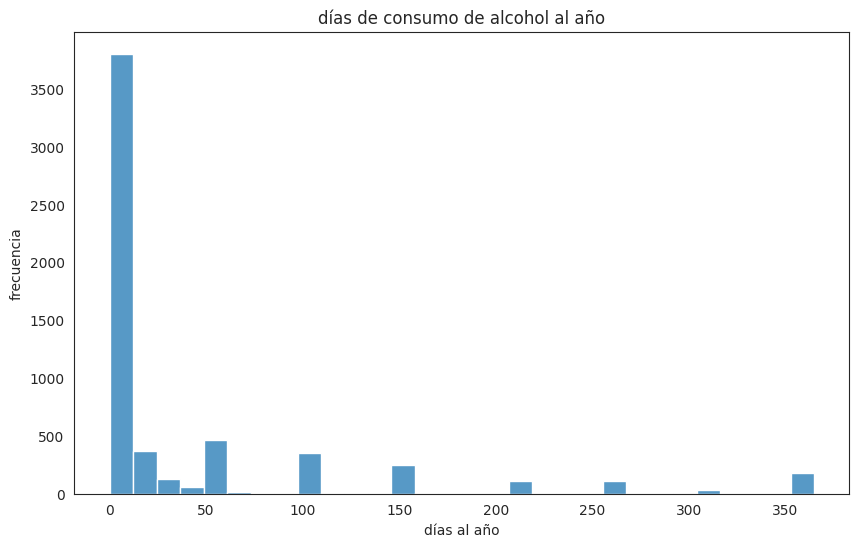

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Usando seaborn para el histograma
sns.histplot(df_alq['Dias_Consumo_Anual'], bins=30, kde=False)

# La magia ocurre aquí:

plt.title('días de consumo de alcohol al año')
plt.xlabel('días al año')
plt.ylabel('frecuencia')
plt.show()

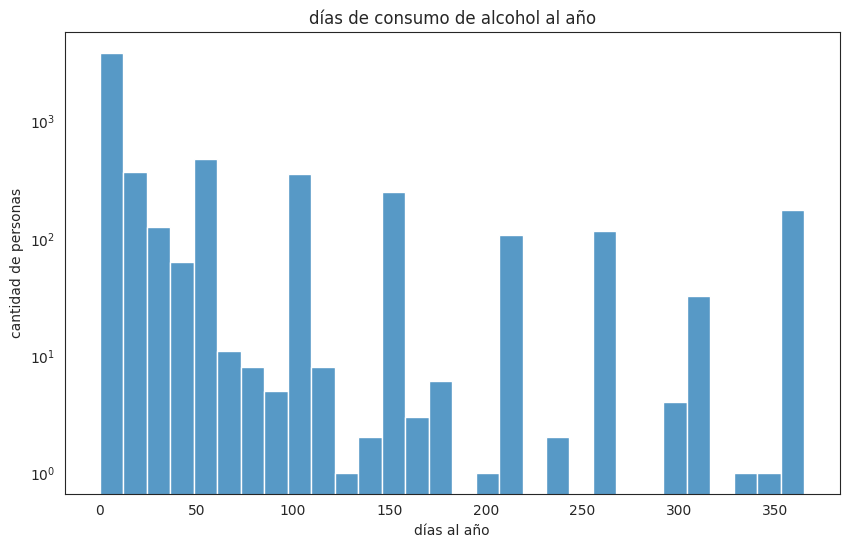

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_alq['Dias_Consumo_Anual'], bins=30, kde=False)

plt.yscale('log')

plt.title('días de consumo de alcohol al año')
plt.xlabel('días al año')
plt.ylabel('cantidad de personas')
plt.show()


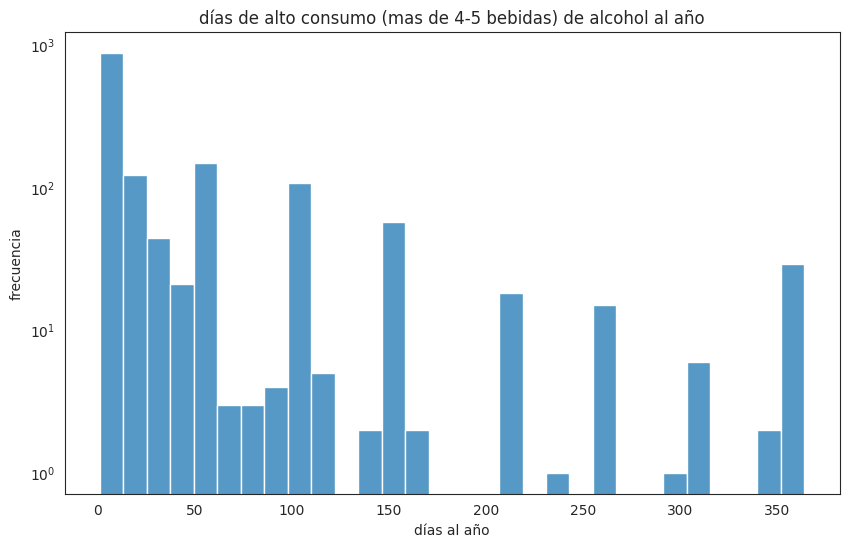

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Usando seaborn para el histograma
df_altos_bebedores = df_alq[df_alq['Dias_Alto_Consumo_Anual'] > 0].copy()
sns.histplot(df_altos_bebedores['Dias_Alto_Consumo_Anual'], bins=30, kde=False)

plt.yscale('log')

plt.title('días de alto consumo (mas de 4-5 bebidas) de alcohol al año')
plt.xlabel('días al año')
plt.ylabel('frecuencia')
plt.show()

/tmp/ipykernel_277309/4148892565.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="Reds", alpha=0.8)


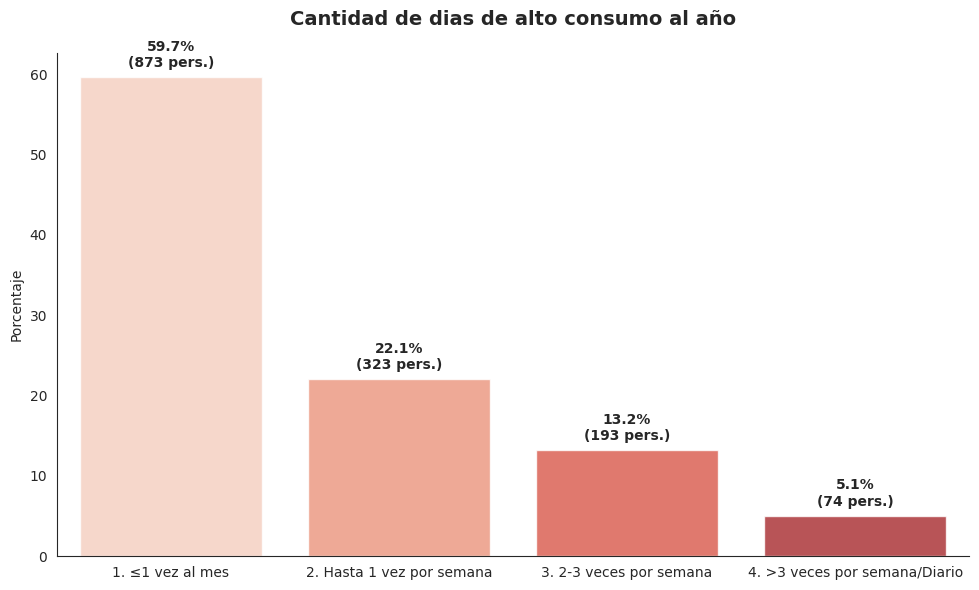

In [25]:
# 1. Definimos categorías de riesgo basadas en la frecuencia anual
def nivel_exposicion(dias):
    if dias <= 12: return "1. ≤1 vez al mes"
    if dias <= 52: return "2. Hasta 1 vez por semana"
    if dias <= 156: return "3. 2-3 veces por semana"
    return "4. >3 veces por semana/Diario"

df_altos_bebedores['Nivel_Cronicidad'] = df_altos_bebedores['Dias_Alto_Consumo_Anual'].apply(nivel_exposicion)

# 2. Visualización: Gráfico de Barras con Porcentajes
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Calculamos porcentajes para que sea comparable
counts = df_altos_bebedores['Nivel_Cronicidad'].value_counts(normalize=True).sort_index() * 100

ax = sns.barplot(x=counts.index, y=counts.values, palette="Reds", alpha=0.8)

# Añadimos las etiquetas de porcentaje y cantidad real
for i, p in enumerate(ax.patches):
    count_real = df_altos_bebedores['Nivel_Cronicidad'].value_counts().sort_index().values[i]
    ax.annotate(f'{p.get_height():.1f}%\n({count_real} pers.)', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontweight='bold')

plt.title('Cantidad de dias de alto consumo al año', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Porcentaje')
plt.xlabel('')
sns.despine()
plt.tight_layout()
plt.show()

## MCQ

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la prevalencia de "Sí" para cada columna
prevalencias = []
for col in cols_booleanas:
    if col in df_mcq.columns:
        # Calculamos el porcentaje de True (Sí)
        porcentaje_si = df_mcq[col].mean() * 100
        prevalencias.append({'Condición': col, 'Prevalencia_Si': porcentaje_si})

# 2. Crear un DataFrame de resumen y ordenar de mayor a menor
df_resumen = pd.DataFrame(prevalencias).sort_values(by='Prevalencia_Si', ascending=False)

# 3. Graficar
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=df_resumen, x='Prevalencia_Si', y='Condición', palette='tab10')

# 4. Agregar las etiquetas de porcentaje al final de cada barra
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5, 
            p.get_y() + p.get_height() / 2, 
            f'{width:.1f}%', 
            ha='left', va='center', fontsize=11, fontweight='bold')

plt.title('Prevalencia de condiciones de salud', fontsize=15, pad=20)
plt.xlabel('Porcentaje de la Población (%)', fontsize=12)
plt.ylabel('Condición de Salud', fontsize=12)
plt.xlim(0, df_resumen['Prevalencia_Si'].max() * 1.15) # Espacio para las etiquetas
sns.despine()
plt.show()

NameError: name 'cols_booleanas' is not defined

# PAQ


In [ ]:
df_paq = pd.read_csv('../data/paq.csv')
df_paq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6085 entries, 0 to 6084
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   SEQN                            6085 non-null   float64
 1   minutos_sedentario_dia          6085 non-null   float64
 2   ejercicio_vigoroso_recreativo   6085 non-null   bool   
 3   ejercicio_moderado_recreativo   6085 non-null   bool   
 4   trabajo_vigoroso                6085 non-null   bool   
 5   trabajo_moderado                6085 non-null   bool   
 6   transporte_activo_bici_caminar  6084 non-null   object 
dtypes: bool(4), float64(2), object(1)
memory usage: 166.5+ KB


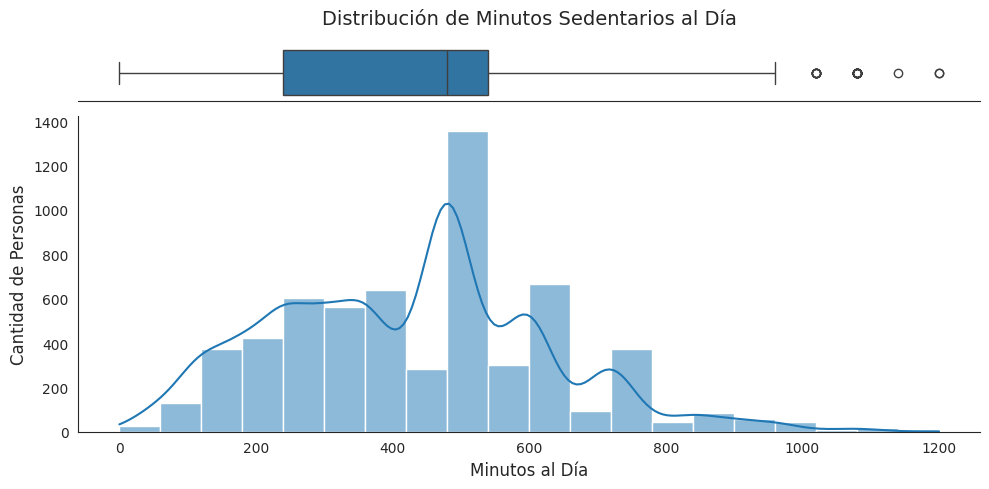

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una figura con dos "pisos" (Boxplot arriba, Histograma abajo)
fig, (ax_box, ax_hist) = plt.subplots(
    nrows=2, 
    sharex=True, 
    figsize=(10, 5), 
    gridspec_kw={"height_ratios": (.15, .85)}
)

# 1. Boxplot (Para identificar outliers)
sns.boxplot(data=df_paq, x='minutos_sedentario_dia', ax=ax_box,)
ax_box.set_title('Distribución de Minutos Sedentarios al Día', fontsize=14, pad=15)
ax_box.set(xlabel='') # Ocultamos el texto del eje X en el gráfico superior

# 2. Histograma con línea de tendencia KDE (Para ver la distribución)
sns.histplot(data=df_paq, x='minutos_sedentario_dia', ax=ax_hist, bins=20, kde=True, )
ax_hist.set_xlabel('Minutos al Día', fontsize=12)
ax_hist.set_ylabel('Cantidad de Personas', fontsize=12)

# Limpieza visual
sns.despine(ax=ax_hist)
sns.despine(ax=ax_box, left=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_211527/2437865768.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_resumen_act, x='Prevalencia_Si', y='Actividad', palette='tab10')


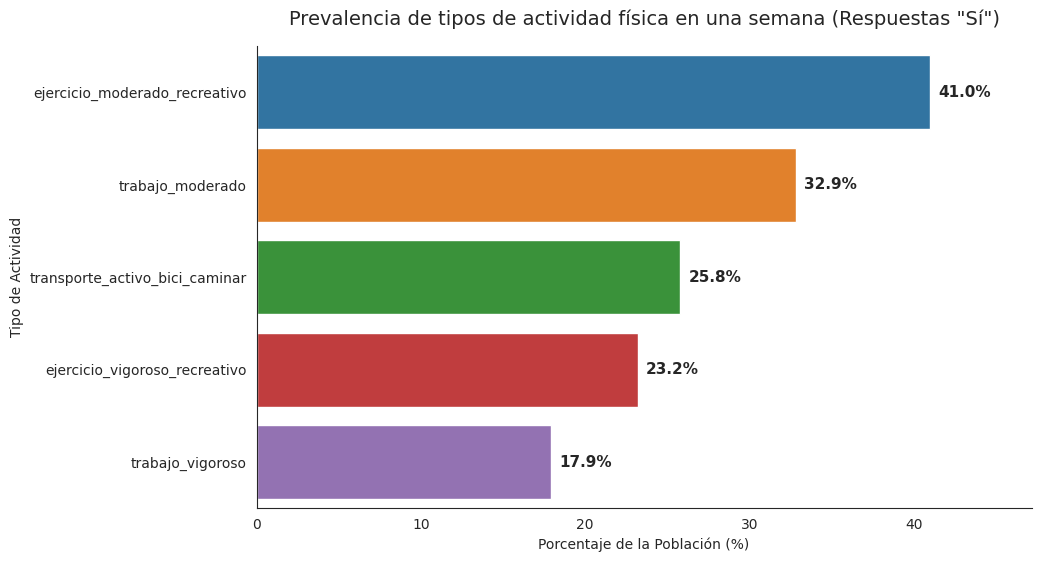

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols_actividad = [
    'ejercicio_vigoroso_recreativo', 'ejercicio_moderado_recreativo', 
    'trabajo_vigoroso', 'trabajo_moderado', 'transporte_activo_bici_caminar'
]

# Calcular la prevalencia de "Sí" (True) para cada tipo de actividad
prevalencias_act = []
for col in cols_actividad:
    if col in df_paq.columns:
        porcentaje_si = df_paq[col].mean() * 100
        prevalencias_act.append({'Actividad': col, 'Prevalencia_Si': porcentaje_si})

# Crear DataFrame y ordenar de mayor a menor
df_resumen_act = pd.DataFrame(prevalencias_act).sort_values(by='Prevalencia_Si', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_resumen_act, x='Prevalencia_Si', y='Actividad', palette='tab10')

# Etiquetas de porcentaje
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5, 
            p.get_y() + p.get_height() / 2, 
            f'{width:.1f}%', 
            ha='left', va='center', fontsize=11, fontweight='bold')

plt.title('Prevalencia de tipos de actividad física en una semana (Respuestas "Sí")', fontsize=14, pad=15)
plt.xlabel('Porcentaje de la Población (%)')
plt.ylabel('Tipo de Actividad')
plt.xlim(0, df_resumen_act['Prevalencia_Si'].max() * 1.15)
sns.despine()
plt.show()

# WHQ

In [28]:
df_whq = pd.read_csv('../data/whq.csv')
df_whq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5955 entries, 0 to 5954
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SEQN                   5955 non-null   float64
 1   altura_pulgadas        5955 non-null   float64
 2   peso_libras            5955 non-null   float64
 3   percibe_peso_como      5955 non-null   object 
 4   intento_bajar_peso     5955 non-null   bool   
 5   conductas_riesgo_peso  5955 non-null   bool   
dtypes: bool(2), float64(3), object(1)
memory usage: 197.9+ KB
